Absolute max (interpolated): 0.01347601 s, amp = 0.986846


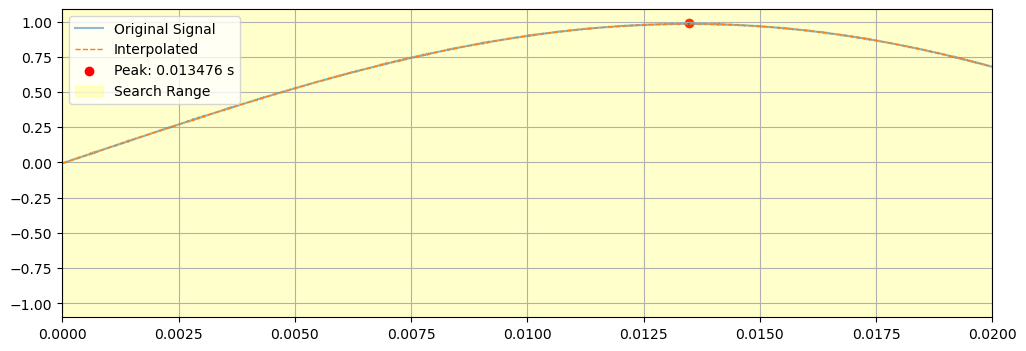

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.interpolate import interp1d

# Load and normalize audio 
sr, y = wavfile.read("/Users/amy/documents/Parkinsons/chirp.wav")

# Mono 
y = y.mean(axis=1) if y.ndim > 1 else y

# Make time spread out using # of y values
y = y / np.max(np.abs(y))
time = np.arange(len(y)) / sr

# Interpolate in high resolution within a small time window
start, end = 0.0, 0.02
fine_time = np.linspace(start, end, 1000 * int(sr * (end - start)))

# Use quadratic interpolation
f = interp1d(time, y, kind='quadratic')  
fine_y = f(fine_time)

# Find precise peak in interpolated signal
peak_time = fine_time[np.argmax(fine_y)]
peak_amp = np.max(fine_y)
print(f"Absolute max (interpolated): {peak_time:.8f} s, amp = {peak_amp:.6f}")

# Plot original and interpolated waveform with peak
plt.figure(figsize=(12, 4))
plt.plot(time, y, alpha=0.5, label="Original Signal")
plt.plot(fine_time, fine_y, '--', lw=1, label="Interpolated")
plt.scatter(peak_time, peak_amp, color='red', label=f"Peak: {peak_time:.6f} s")
plt.axvspan(start, end, color='yellow', alpha=0.2, label="Search Range")
plt.xlim(0, 0.1)
plt.grid(True)
plt.legend()
plt.show()



In [35]:
# Find sampling rate = 48 kHz, 0.020833 ms/sample -- the error will be at most like 0.5 of the smallest gradation

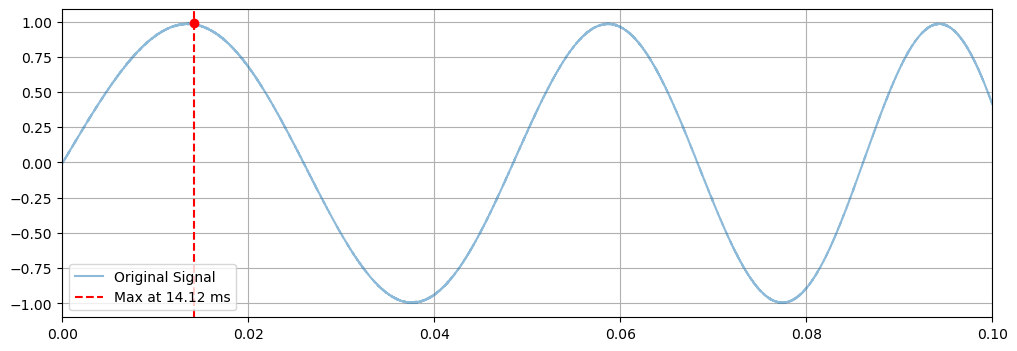

Maximum absolute amplitude within first 20 ms:
Value = 0.986731, Time = 0.014125 s, Sample = 678
Value  before= 0.976959, Time = 0.014104 s, Sample = 677
difference: 2.083333333333451e-08ms


In [143]:
# Same thing just compare to value before and after the wanted sample

import numpy as np
from scipy.io import wavfile
import matplotlib.pyplot as plt

sr, y = wavfile.read("/Users/amy/documents/Parkinsons/chirp.wav")

if y.ndim > 1:
    y = y.mean(axis=1) 

# Normalize to [-1, 1]
y = y / np.max(np.abs(y))

# Calculate number of samples in 0.02 seconds
max_search_time = 0.02 
samples_to_check = int(sr * max_search_time) # this is the (sampling rate x time) 

# Slice by frame, then search for max in the first 0.02 seconds
y_segment = y[:samples_to_check]


max_idx = np.argmax(np.abs(y_segment))  
max_val = y_segment[max_idx]

# convert index to time
max_time = max_idx / sr  

# Plotting
time = np.arange(len(y)) / sr
plt.figure(figsize=(12, 4))
plt.plot(time, y, label="Original Signal", alpha=0.5)
plt.axvline(max_time, color='r', linestyle='--', label=f'Max at {max_time*1000:.2f} ms')
plt.plot(max_time, max_val, 'ro')
plt.xlim(0, 0.1)
plt.legend()
plt.grid(True)
plt.show()

# Print result
print(f"Maximum absolute amplitude within first {max_search_time*1000:.0f} ms:")
print(f"Value = {max_val:.6f}, Time = {max_time:.6f} s, Sample = {max_idx}")


index = max_idx - 1
value = y_segment[index]
time = index/sr


print(f"Value  before= {value:.6f}, Time = {time:.6f} s, Sample = {index}")
print("difference: " + str((max_time - time)*0.001) + "ms")

In [7]:
import numpy as np
import librosa

# Load audio
y, sr = librosa.load("/Users/amy/documents/Parkinsons/chirp.wav")

# Extract pitch and magnitude
p, m = librosa.piptrack(y=y, sr=sr)

# Get dominant pitches > 0 Hz
freqs = np.array([p[m[:, t].argmax(), t] for t in range(p.shape[1]) if p[m[:, t].argmax(), t] > 20])

# Convert to notes
notes = librosa.hz_to_note(freqs)

# Print note range
print("Lowest note:", notes[freqs.argmin()], f"({freqs.min():.2f} Hz)")
print("Highest note:", notes[freqs.argmax()], f"({freqs.max():.2f} Hz)")

Lowest note: E3 (160.35 Hz)
Highest note: A♯7 (3757.81 Hz)


ffmpeg version 7.1.1 Copyright (c) 2000-2025 the FFmpeg developers
  built with Apple clang version 16.0.0 (clang-1600.0.26.6)
  configuration: --prefix=/opt/homebrew/Cellar/ffmpeg/7.1.1_2 --enable-shared --enable-pthreads --enable-version3 --cc=clang --host-cflags= --host-ldflags='-Wl,-ld_classic' --enable-ffplay --enable-gnutls --enable-gpl --enable-libaom --enable-libaribb24 --enable-libbluray --enable-libdav1d --enable-libharfbuzz --enable-libjxl --enable-libmp3lame --enable-libopus --enable-librav1e --enable-librist --enable-librubberband --enable-libsnappy --enable-libsrt --enable-libssh --enable-libsvtav1 --enable-libtesseract --enable-libtheora --enable-libvidstab --enable-libvmaf --enable-libvorbis --enable-libvpx --enable-libwebp --enable-libx264 --enable-libx265 --enable-libxml2 --enable-libxvid --enable-lzma --enable-libfontconfig --enable-libfreetype --enable-frei0r --enable-libass --enable-libopencore-amrnb --enable-libopencore-amrwb --enable-libopenjpeg --enable-libspeex

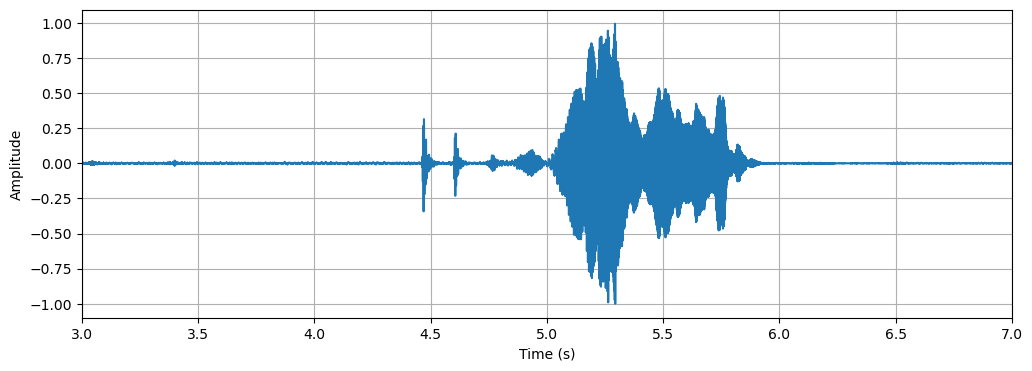

In [20]:
# Code to extract audio from video
import ffmpeg
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile

video_path = "/Users/amy/documents/Parkinsons/R7.MOV"
audio_path = "extracted_audio.wav"

# Extract audio using ffmpeg
(
    ffmpeg
    .input(video_path)
    .output(audio_path, ac=1, ar='44100') # what is the glasses 30 fps
    .overwrite_output()
    .run()
)

# sampling rate, amplitude
sr, y = wavfile.read(audio_path)
y = y.astype(np.float32)

# Normalize and make time axis
y = y / np.max(np.abs(y))
time = np.arange(len(y)) / sr

plt.figure(figsize=(12,4))
plt.plot(time, y)
plt.xlim(3, 7)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()



Closest time to 500 Hz: 5.2825 sec (Pitch: 495.3 Hz)


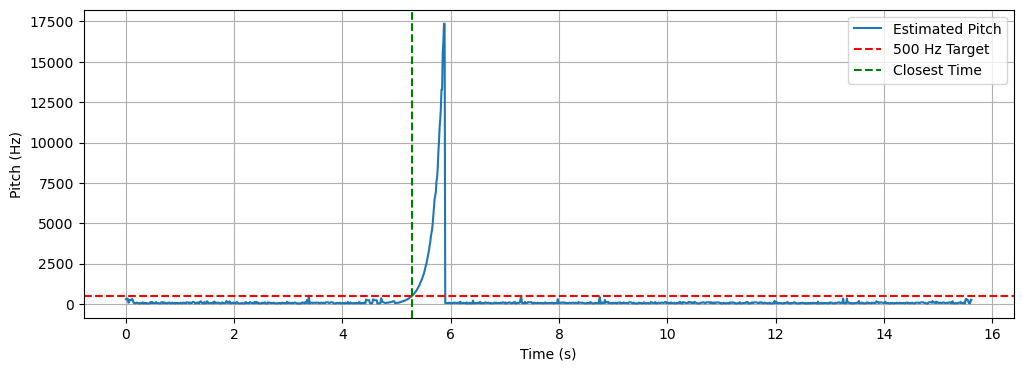

In [22]:
# Pitch test code (exponential chirp)

import numpy as np
from scipy.io import wavfile
import matplotlib.pyplot as plt

# Load audio
sr, y = wavfile.read("/Users/amy/documents/Parkinsons/R7.wav")
if y.ndim > 1:
    y = y.mean(axis=1) 
y = y / np.max(np.abs(y))  

# Parameters
frame_size = 2048
hop_size = 512

# Compute pitch per frame
pitches = []
times = []

for i in range(0, len(y) - frame_size, hop_size):

    # Set up the frame intervals
    frame = y[i:i+frame_size]

    # Reduce leakage
    windowed = frame * np.hanning(len(frame))

    # Compute the corresponding frequency bins
    spectrum = np.abs(np.fft.rfft(windowed))
    freqs = np.fft.rfftfreq(len(frame), d=1/sr)

    # Find index for peak frequency in specific interval
    peak_index = np.argmax(spectrum)

    # Find the frequency
    pitch = freqs[peak_index]

    # Store the estimated pitch and corresponding time
    pitches.append(pitch)
    times.append(i / sr)

# Find time closest to 500 Hz
pitches = np.array(pitches)
times = np.array(times)
closest_index = np.argmin(np.abs(pitches - 500))
print(f"Closest time to 500 Hz: {times[closest_index]:.4f} sec (Pitch: {pitches[closest_index]:.1f} Hz)")

plt.figure(figsize=(12, 4))
plt.plot(times, pitches, label="Estimated Pitch")
plt.axhline(500, color='red', linestyle='--', label='500 Hz Target')
plt.axvline(times[closest_index], color='green', linestyle='--', label='Closest Time')
plt.xlabel("Time (s)")
plt.ylabel("Pitch (Hz)")
plt.legend()
plt.grid(True)
plt.show()

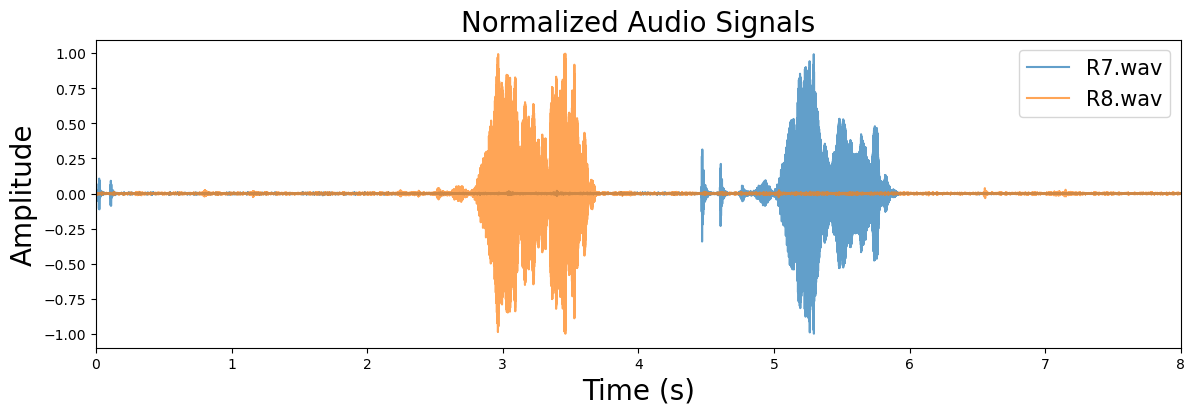

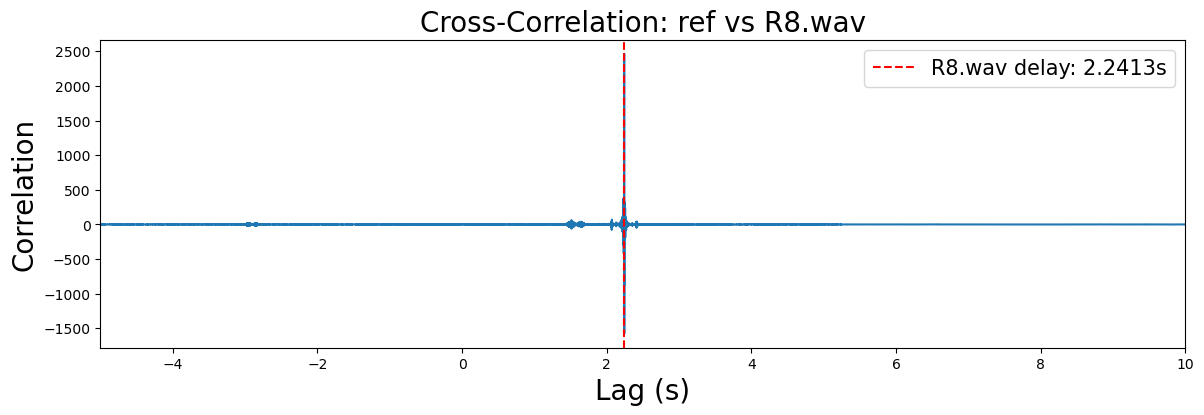

R8.wav delay: 98843 samples (2.2413 seconds)


In [58]:
# Try with functions and multiple files to actually use cross-correlation

# Libraries
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.signal import correlate, resample, resample_poly


# Function for same sampling rate
def load_and_resample(path, target_sr=None):
    
    sr, data = wavfile.read(path) # SAMPLING RATE, Numpy ARRAY OF AUDIO
    
    if data.ndim == 2:  # Stereo to mono 
        
        data = data.mean(axis=1) # average left and right channels for each time point
        
    if target_sr and sr != target_sr: # if sampling rates differ:
        
        duration = len(data) / sr     # Calculates the duration of the audio in seconds.
    
        data = resample(data, int(duration * target_sr)) # How many samples the audio should have at the new sample rate (an interpolation function)
        
        sr = target_sr # new sampling rate
        
    return sr, data / np.max(np.abs(data))  


# Function for CROSS-CORRELATION
def cross_corr(ref, target, sr):
    corr = correlate(ref, target, mode='full')
    lags = np.arange(-len(target) + 1, len(ref))  # <-- this should be lags (plural) how does it work??
    delay = lags[np.argmax(corr)]                 # <-- match the variable name
    delay_sec = delay / sr
    return corr, lags, delay, delay_sec



# AUDIO paths go here!
paths = [
    "/Users/amy/documents/Parkinsons/R7.wav",    
    "/Users/amy/documents/Parkinsons/R8.wav",
]

# Pick a Reference audio (first one...)
ref_sr, ref_data = load_and_resample(paths[0])
all_signals = [(ref_data, paths[0])]


# Load and resample others to match reference
for path in paths[1:]:
    _, data = load_and_resample(path, ref_sr)
    all_signals.append((data, path))

# Plot all signals
plt.figure(figsize=(14, 4))
for signal, path in all_signals:
    plt.plot(np.linspace(0, len(signal)/ref_sr, len(signal)), signal, label=path.split('/')[-1], alpha=0.7)

# Titles
plt.title("Normalized Audio Signals", fontsize=20)
plt.xlabel("Time (s)", fontsize=20)
plt.ylabel("Amplitude", fontsize=20)
plt.legend(fontsize=15)
plt.xlim(0, 8)

plt.show()

# Cross correlate and plot
for signal, path in all_signals[1:]:
    corr, lags, delay_samples, delay_seconds = cross_corr(ref_data, signal, ref_sr)
    plt.figure(figsize=(14, 4))
    plt.plot(lags / ref_sr, corr)
    plt.axvline(delay_seconds, color='red', linestyle='--', label=f"{path.split('/')[-1]} delay: {delay_seconds:.4f}s")
    plt.title(f"Cross-Correlation: ref vs {path.split('/')[-1]}", fontsize=20)
    plt.xlabel("Lag (s)", fontsize=20)
    plt.ylabel("Correlation", fontsize=20)
    plt.legend(fontsize=15)
   # plt.grid()
    plt.xlim(-5, 10)
    plt.show()
    print(f"{path.split('/')[-1]} delay: {delay_samples} samples ({delay_seconds:.4f} seconds)")







In [28]:
# Code to make side-by-side video alignment so we can better observe

import numpy as np
import cv2
from scipy.io import wavfile
from scipy.signal import correlate, resample

# Same functions...
def load_and_resample(path, target_sr=None):
    sr, data = wavfile.read(path)
    if data.ndim == 2: data = data.mean(axis=1)
    if target_sr and sr != target_sr:
        duration = len(data) / sr
        data = resample(data, int(duration * target_sr))
        sr = target_sr
    return sr, data / np.max(np.abs(data))

def cross_corr(ref, target, sr):
    corr = correlate(ref, target, mode='full')
    lags = np.arange(-len(target) + 1, len(ref))
    delay = lags[np.argmax(corr)]
    return delay, delay / sr

# Aligning function
def align_side_by_side(video1_path, video2_path, delay_seconds, output_path):

    # Capture both of the videos
    cap1, cap2 = cv2.VideoCapture(video1_path), cv2.VideoCapture(video2_path)

    # Frames per second
    fps = cap1.get(cv2.CAP_PROP_FPS)

    # timexfps = frames
    delay_frames = int(round(delay_seconds * fps))
    print(f"Calculated delay: {delay_seconds:.4f}s → skipping {abs(delay_frames)} frames from {'video2' if delay_frames>0 else 'video1' if delay_frames<0 else 'none'}")

    # frame dimensions, resize.
    w1, h1 = int(cap1.get(cv2.CAP_PROP_FRAME_WIDTH)), int(cap1.get(cv2.CAP_PROP_FRAME_HEIGHT))
    w2, h2 = int(cap2.get(cv2.CAP_PROP_FRAME_WIDTH)), int(cap2.get(cv2.CAP_PROP_FRAME_HEIGHT))
    h = min(h1, h2)
    new_w1, new_w2 = int(w1 * h / h1), int(w2 * h / h2)

    if delay_frames > 0:
        for _ in range(delay_frames): cap2.read() #video2 is delayed → skip its early frames
    elif delay_frames < 0:
        for _ in range(-delay_frames): cap1.read()


    ## new stuff!!

    # Set up video writer with combined width
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_path, fourcc, fps, (new_w1 + new_w2, h))

    # Process frames and write side-by-side video
    while True:
        ret1, f1 = cap1.read()
        ret2, f2 = cap2.read()

        # Stop if either video ends
        if not ret1 or not ret2: break
            
        f1 = cv2.resize(f1, (new_w1, h))
        f2 = cv2.resize(f2, (new_w2, h))
        
        out.write(cv2.hconcat([f1, f2]))

    # release
    cap1.release()
    cap2.release()
    out.release()
    print(f"Saved aligned video to {output_path}")

#Paths 
audio1 = "/Users/amy/documents/Parkinsons/R7.wav"
audio2 = "/Users/amy/documents/Parkinsons/R8.wav"
video1 = "/Users/amy/documents/Parkinsons/R7.MOV"
video2 = "/Users/amy/documents/Parkinsons/R8.MOV"
output_video = "/Users/amy/documents/Parkinsons/aligned_video!.mp4"

#Process
ref_sr, ref_data = load_and_resample(audio1) 
_, target_data = load_and_resample(audio2, ref_sr)

delay_samples, delay_seconds = cross_corr(ref_data, target_data, ref_sr)
corrected_delay_seconds = -delay_seconds  # flip sign
print(f"Delay: {delay_samples} samples, {delay_seconds:.4f} seconds")

align_side_by_side(video1, video2, corrected_delay_seconds, output_video)




Delay: 98843 samples, 2.2413 seconds
Calculated delay: -2.2413s → skipping 67 frames from video1
Saved aligned video to /Users/amy/documents/Parkinsons/aligned1.mp4


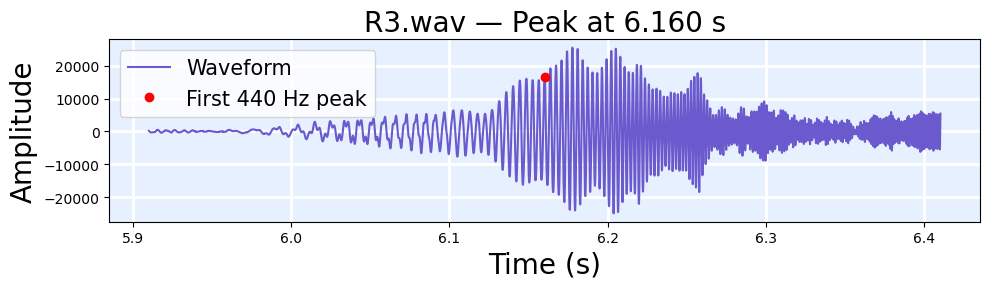

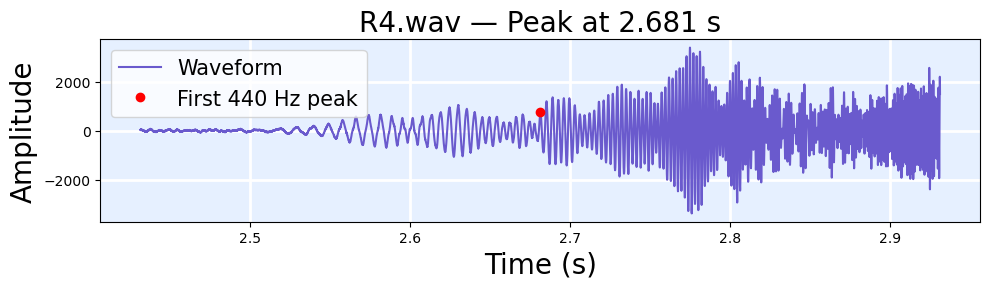

In [62]:
import os
import numpy as np
import scipy.signal as signal
import scipy.io.wavfile as wav
import matplotlib.pyplot as plt

# Configs
folder = "/Users/amy/documents/Parkinsons"    
file_names = ["R3.wav", "R4.wav"]              
target_freq = 440                               # Note to detect in hertz
tolerance = 5                                   # ± Hz range to accept?? 




# Must respect Nyquist frequency!!!!!!! (haven't done)
# Should try to normalize
# Should we use peak???




# FFT analysis window and step durations (in seconds)
# Window length affects frequency resolution
# Step duration affects time resolution.
# We move the FFT window forward by 0.01 seconds each time

# window must be longer than period

win_dur, step_dur = 0.05, 0.01                  


# Plot window 0.25 secs around peak (±s)  
plot_half_win = 0.25              



#Larger window = better frequency resolution, but worse time resolution


# Function

def load_audio(path):
    # If the WAV is multi‑channel (stereo, etc.), keep only the first channel.
    # Convert to 32‑bit float 
    fs, data = wav.read(path)
    return fs, data[:, 0] if data.ndim > 1 else data.astype(np.float32)

def get_dominant_freq(chunk, fs):
    windowed = chunk * np.hanning(len(chunk))    # Apply Hann window apparently this reduces spectral leakage
    freqs = np.fft.rfftfreq(len(chunk), d=1/fs)  # Generate frequency bins for (non‑negative freqs) FFT
    spectrum = np.abs(np.fft.rfft(windowed))     # Perform real FFT and get magnitude spectrum
    return freqs[np.argmax(spectrum)]            # Return frequency corresponding to highest magnitude (we want the most important freq)


def find_first_freq_time(audio, fs):
    win_len = int(win_dur * fs)                                             # Number of samples in each FFT window
    step_len = int(step_dur * fs)                                           # hop size in samples
    for i in range(0, len(audio) - win_len, step_len):
        chunk = audio[i:i + win_len]                                        # Extract audio chunk (Current analysis frame)
        if abs(get_dominant_freq(chunk, fs) - target_freq) <= tolerance:    # Check if dominant freq ≈ target, return start time
            return i / fs  # time in seconds
    return None

def find_peak_at_time(audio, fs, center_time, search_win=0.1):

    # low and high interval is where the window extends to and from
    lo = max(0, int((center_time - search_win / 2) * fs))
    hi = min(len(audio), int((center_time + search_win / 2) * fs))
    peaks, _ = signal.find_peaks(audio[lo:hi]) # Detect peaks in the slice
    return (lo + peaks[0]) if peaks.size else None # Convert peak to global audio index

def plot_wave(audio, fs, peak_idx, title):
    half = int(plot_half_win * fs)
    lo = max(0, peak_idx - half)
    hi = min(len(audio), peak_idx + half)
    t = np.arange(lo, hi) / fs

    fig, ax = plt.subplots(figsize=(10, 3))

    ax.set_facecolor("#e6f0ff")

    # Plot waveform and peak
    ax.plot(t, audio[lo:hi], color='slateblue', linewidth=1.5, label="Waveform")
    ax.plot(peak_idx / fs, audio[peak_idx], 'ro', label="First " + str(target_freq) + " Hz peak")


    ax.set_title(f"{title} — Peak at {peak_idx / fs:.3f} s", fontsize = 20)
    ax.set_xlabel("Time (s)", fontsize = 20)
    ax.set_ylabel("Amplitude", fontsize = 20)
    ax.grid(True, which='both', color='white', linestyle='-', linewidth=2)
    ax.legend(fontsize = 15)
    plt.tight_layout()
    plt.show()



# MAIN PART
for name in file_names:
    path = os.path.join(folder, name)

    fs, audio = load_audio(path)
    time_440 = find_first_freq_time(audio, fs)

    peak_idx = find_peak_at_time(audio, fs, time_440)
  
    plot_wave(audio, fs, peak_idx, name)
    


In [40]:
# Nothing too important, just make sure fremarate. phone was 29.97 fps... not exactly 30... source of error

In [32]:
# VIDEO AND AUDIO SEPARATE CODE

import numpy as np, cv2
from scipy.io import wavfile
from scipy.signal import correlate, resample
from scipy.io.wavfile import write


# Load and normalize audio, optionally resampling
def load_audio(path, target_sr=None):
    
    sr, data = wavfile.read(path) # data = audio waveform
    
    if data.ndim == 2: data = data.mean(axis=1) 
        
    if target_sr and sr != target_sr:
        data = resample(data, int(len(data) * target_sr / sr))
        sr = target_sr
    return sr, data / np.max(np.abs(data))  


# Get delay (samples + seconds) using cross-correlation
def get_delay(ref, target, sr):
    corr = correlate(ref, target, mode='full')
    delay = np.argmax(corr) - len(target) + 1 # Find lag where signals match best (index where highest dot-product sum - len of shifting signal) + 1
    return delay, delay / sr

# Shift signal left/right by padding
def shift_signal(sig, delay):

    
    if delay > 0:
        # Pad beginning with 'delay' zeros, cut off end to maintain length
        return np.pad(sig, (delay, 0))[:len(sig)]
    elif delay < 0:

        # Remove first '-delay' samples, pad with zeros at the end
        return np.pad(sig[-delay:], (0, len(sig) + delay))
    return sig


# Save stereo file: ref in left, aligned in right
def save_stereo(ref, aligned, sr, out_path):
    m = min(len(ref), len(aligned)) # Trim both to same length
    stereo = np.stack([ref[:m], aligned[:m]], axis=1) # Combine stereo
    write(out_path, sr, np.int16(stereo * 32767))
    print(f"Saved stereo audio to: {out_path}")

# Combine two videos side by side, with frame sync
def combine_videos(v1, v2, delay_sec, out_path):
    cap1, cap2 = cv2.VideoCapture(v1), cv2.VideoCapture(v2)
    fps = cap1.get(5)  # Frames per second
    df = int(round(delay_sec * fps)) # Delay in number of frames
    print(f"Delay (seconds): {delay_sec:.4f}, Delay (frames): {df}")

    cap1.set(1, max(0, -df))
    cap2.set(1, max(0, df))

    w1, h1 = int(cap1.get(3)), int(cap1.get(4))
    w2, h2 = int(cap2.get(3)), int(cap2.get(4))
    h = min(h1, h2)
    w1, w2 = int(w1 * h / h1), int(w2 * h / h2)


    # Prepare output writer with combined width
    out = cv2.VideoWriter(out_path, cv2.VideoWriter_fourcc(*'mp4v'), fps, (w1 + w2, h))
   
    while True:
        r1, f1 = cap1.read()
        r2, f2 = cap2.read()
        if not r1 or not r2: break
        f1, f2 = cv2.resize(f1, (w1, h)), cv2.resize(f2, (w2, h))
        out.write(cv2.hconcat([f1, f2]))
    cap1.release(), cap2.release(), out.release()
    print(f"Saved aligned video to {out_path}")



# PATHS 
a1 = "/Users/amy/documents/Parkinsons/R7.wav"
a2 = "/Users/amy/documents/Parkinsons/R8.wav"
v1 = "/Users/amy/documents/Parkinsons/R7.MOV"
v2 = "/Users/amy/documents/Parkinsons/R8.MOV"

out_video = "/Users/amy/documents/Parkinsons/A_VIDE0_DEMO.mp4"
out_audio = "/Users/amy/documents/Parkinsons/A_AUDIO_DEMO.wav"

# Process
sr, ref = load_audio(a1)
_, tgt = load_audio(a2, sr)

delay_samples, delay_sec = get_delay(ref, tgt, sr)
print(f"Raw delay: {delay_samples} samples, {delay_sec:.4f} seconds")

corrected_sec = -delay_sec  # flip sign to align video2 to video1
print(f"Corrected delay (to apply): {corrected_sec:.4f} seconds")

aligned = shift_signal(tgt, delay_samples)

# save file
save_stereo(ref, aligned, sr, out_audio)
combine_videos(v1, v2, corrected_sec, out_video)


Raw delay: 98843 samples, 2.2413 seconds
Corrected delay (to apply): -2.2413 seconds
Saved stereo audio to: /Users/amy/documents/Parkinsons/A_AUDIO_DEMO.wav
Delay (seconds): -2.2413, Delay (frames): -67
Saved aligned video to /Users/amy/documents/Parkinsons/A_VIDE0_DEMO.mp4
